In [1]:
# pipenv install pandas seaborn plotly scikit-learn matplotlib ipywidgets ipykernel nbformat mlxtend

# EDA
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from mlxtend.frequent_patterns import apriori, association_rules

# EDA

## Loading the dataset

In [4]:
df_transactions = pd.read_csv('./datasets/transactions_dept.csv', sep=',')
df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   POS Txn  4539 non-null   uint64
 1   Dept     4539 non-null   str   
 2   ID       4539 non-null   int64 
 3   Sales U  4539 non-null   int64 
dtypes: int64(2), str(1), uint64(1)
memory usage: 142.0 KB


In [5]:
df_transactions.head(10)

,POS Txn,Dept,ID,Sales U
0,16120100160021008773,0261:HOSIERY,250,2
1,16120100160021008773,0634:VITAMINS & HLTH AIDS,102,1
2,16120100160021008773,0879:PET SUPPLIES,158,2
3,16120100160021008773,0973:CANDY,175,2
4,16120100160021008773,0982:SPIRITS,176,1
5,16120100160021008773,0983:WINE,177,4
6,16120100160021008773,0991:TOBACCO,179,2
7,16120100160021008774,0597:HEALTH AIDS,93,1
8,16120100160021008774,0604:PERSONAL CARE,100,5
9,16120100160021008775,0819:PRE-RECORDED A/V,135,1


In [8]:
df_transactions.rename(
    columns={
        "POS Txn": "ID_Transaction",
        "Dept": "Department",
        "ID": "ID_Department",
        "Sales U": "Quantity_Sold"
    }, inplace=True
)

df_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID_Transaction  4539 non-null   uint64
 1   Department      4539 non-null   str   
 2   ID_Department   4539 non-null   int64 
 3   Quantity_Sold   4539 non-null   int64 
dtypes: int64(2), str(1), uint64(1)
memory usage: 142.0 KB


In [ ]:
# Department Quantity
df_transactions['Department'].nunique()

160

In [10]:
# ID Department Quantity
df_transactions['ID_Department'].nunique()

160

In [12]:
# Department Quantity
df_transactions['ID_Transaction'].nunique()

2064

In [13]:
# Can a department appear more than once in the same transaction?
len(df_transactions.groupby(['ID_Transaction', 'Department'])) != len(df_transactions)

False

In [ ]:
# Check for lower or equal to zero quantity sold <= 0
len(df_transactions[df_transactions['Quantity_Sold'] <= 0])

149

In [15]:
# Removing row with quantity sold <= 0
df_transactions = df_transactions[df_transactions['Quantity_Sold'] > 0]

## Exploring the dataset based on some business questions

### Which departments have the highest transaction volume and the largest number of units sold?

In [21]:
# Number of unique transactions in which each department appears
# Transaction volume
count_department_transactions = df_transactions.value_counts('Department').head(10)

fig_transaction_volume_top10 = px.bar(count_department_transactions, color=count_department_transactions.index, orientation='h')
fig_transaction_volume_top10.update_layout(showlegend=False)
fig_transaction_volume_top10.show()

In [ ]:
# Number of unique transactions in which each department appears
# Transaction volume
sum_department_units_sold_top10 = df_transactions.groupby('Department')['Quantity_Sold'].sum().sort_values(ascending=False).head(10)

fig_units_sold_top10 = px.bar(sum_department_units_sold_top10, color=sum_department_units_sold_top10.index, orientation='h')
fig_units_sold_top10.update_layout(showlegend=False)
fig_units_sold_top10.show()

In [ ]:
# Number of unique transactions in which each department appears
# Unity Sold
count_department_transactions_top10 = df_transactions.value_counts('Department').head(10)

count_department_transactions_top10 = px.bar(count_department_transactions_top10, color=count_department_transactions_top10.index, orientation='h')
count_department_transactions_top10.update_layout(showlegend=False)

count_department_transactions_top10.show()

In [27]:
# Combine the two “Top 10” charts to display them side by side

fig_question_1 = make_subplots(rows=1, cols=2, subplot_titles=("Transactions Volume", "Units Sold"))

for trace in fig_transaction_volume_top10['data']:
    fig_question_1.add_trace(trace, row=1, col=1)

for trace in fig_units_sold_top10['data']:
    fig_question_1.add_trace(trace, row=1, col=2)

fig_question_1.update_layout(height=800, width=1300, title_text='Top 10 Departments', showlegend=False)
fig_question_1.show()

### Which departments have the highest variation in units sold per transaction?

In [35]:
# Calculate the standard deviation
std_department_units_sold_top20 = df_transactions.groupby('Department')['Quantity_Sold'].std().sort_values(ascending=False).head(20)

fig_variation_units_sold_top20 = px.bar(std_department_units_sold_top20, color=std_department_units_sold_top20.index, orientation='h')
fig_variation_units_sold_top20.update_layout(showlegend=False)
fig_variation_units_sold_top20.show()

### What is the breakdown of units sold by department across the various transactions?

In [33]:
# Evaluate the position measures for the Quantity_Sold variable
px.box(df_transactions, x='Department', y='Quantity_Sold')

### Which departments have the highest average number of units sold per transaction?

In [36]:
# Calculate the mean
mean_department_units_sold_top20 = df_transactions.groupby('Department')['Quantity_Sold'].mean().sort_values(ascending=False).head(20)

fig_mean_units_sold_top20 = px.bar(mean_department_units_sold_top20, color=mean_department_units_sold_top20.index, orientation='h')
fig_mean_units_sold_top20.update_layout(showlegend=False)
fig_mean_units_sold_top20.show()

In [37]:
# Combine the two “Top 20” charts to display them side by side

fig_question_4 = make_subplots(rows=1, cols=2, subplot_titles=("Standard Deviation", "Mean"))

for trace in fig_variation_units_sold_top20['data']:
    fig_question_4.add_trace(trace, row=1, col=1)

for trace in fig_mean_units_sold_top20['data']:
    fig_question_4.add_trace(trace, row=1, col=2)

fig_question_4.update_layout(height=800, width=1300, title_text='Top 20 Departments', showlegend=False)
fig_question_4.show()

# Model Training

## Preparing the dataset with pivot table

In [ ]:
# ID_Transaction as ROW, Department as COL and Quantity_Sold sum as Value
df_transactions_pivot = df_transactions.pivot_table(
                                                        index='ID_Transaction',
                                                        columns='Department',
                                                        values='Quantity_Sold',
                                                        aggfunc='sum'
                                                    )

df_transactions_pivot.info()

<class 'pandas.DataFrame'>
Index: 1943 entries, 16120100160021008773 to 16120100160221001467
Columns: 156 entries, 0002:BARBER RETAIL to 0999:UNSCANNED ITEMS
dtypes: float64(156)
memory usage: 2.3 MB


In [39]:
df_transactions_pivot.head(10)

Department,0002:BARBER RETAIL,0009:FLORAL SERV/SUPPLIES,0012:LOCAL GIFTS/FOODS,0014:REPAIRS,0016:FINANCIAL SERVICES,0018:OTHER DIRECT SERVICE,0033:VENDING RETAIL,0056:SOUVENIR,0066:VENDING/AMUSEMENT MA,0071:BEAUTY RETAIL,...,0941:BEDDING,0961:GENERAL GROCERIES,0962:BEVERAGES,0965:PERISHABLES,0973:CANDY,0982:SPIRITS,0983:WINE,0984:BEER,0991:TOBACCO,0999:UNSCANNED ITEMS
ID_Transaction,,,,,,,,,,,,,,,,,,,,,
16120100160021008773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,1.0,4.0,NaN,2.0,NaN
16120100160021008774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
16120100160021008776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
16120100160021008778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,1.0,NaN
16120100160021008779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,NaN,NaN
16120100160021008780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16120100160021008781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,1.0,NaN,2.0,NaN,NaN,NaN


In [40]:
# Convert the data on pivot table to boolean
df_transactions_pivot = df_transactions_pivot.map(lambda x: True if x > 0 else False)
df_transactions_pivot.head(10)

Department,0002:BARBER RETAIL,0009:FLORAL SERV/SUPPLIES,0012:LOCAL GIFTS/FOODS,0014:REPAIRS,0016:FINANCIAL SERVICES,0018:OTHER DIRECT SERVICE,0033:VENDING RETAIL,0056:SOUVENIR,0066:VENDING/AMUSEMENT MA,0071:BEAUTY RETAIL,...,0941:BEDDING,0961:GENERAL GROCERIES,0962:BEVERAGES,0965:PERISHABLES,0973:CANDY,0982:SPIRITS,0983:WINE,0984:BEER,0991:TOBACCO,0999:UNSCANNED ITEMS
ID_Transaction,,,,,,,,,,,,,,,,,,,,,
16120100160021008773,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,False,True,False
16120100160021008774,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16120100160021008775,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
16120100160021008776,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
16120100160021008777,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
16120100160021008778,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
16120100160021008779,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,False,False
16120100160021008780,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16120100160021008781,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,True,False,False,False


In [41]:
# Removing the title Department
df_transactions_pivot = df_transactions_pivot.rename_axis(None, axis=1)

In [42]:
# Drop / remove id_transactions column
df_transactions_pivot.reset_index(inplace=True)

In [43]:
df_transactions_pivot.drop(columns=['ID_Transaction'], inplace=True)

In [48]:
df_transactions_pivot.info()

<class 'pandas.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Columns: 156 entries, 0002:BARBER RETAIL to 0999:UNSCANNED ITEMS
dtypes: bool(156)
memory usage: 296.1 KB


## Correlation Between departments

<Axes: >

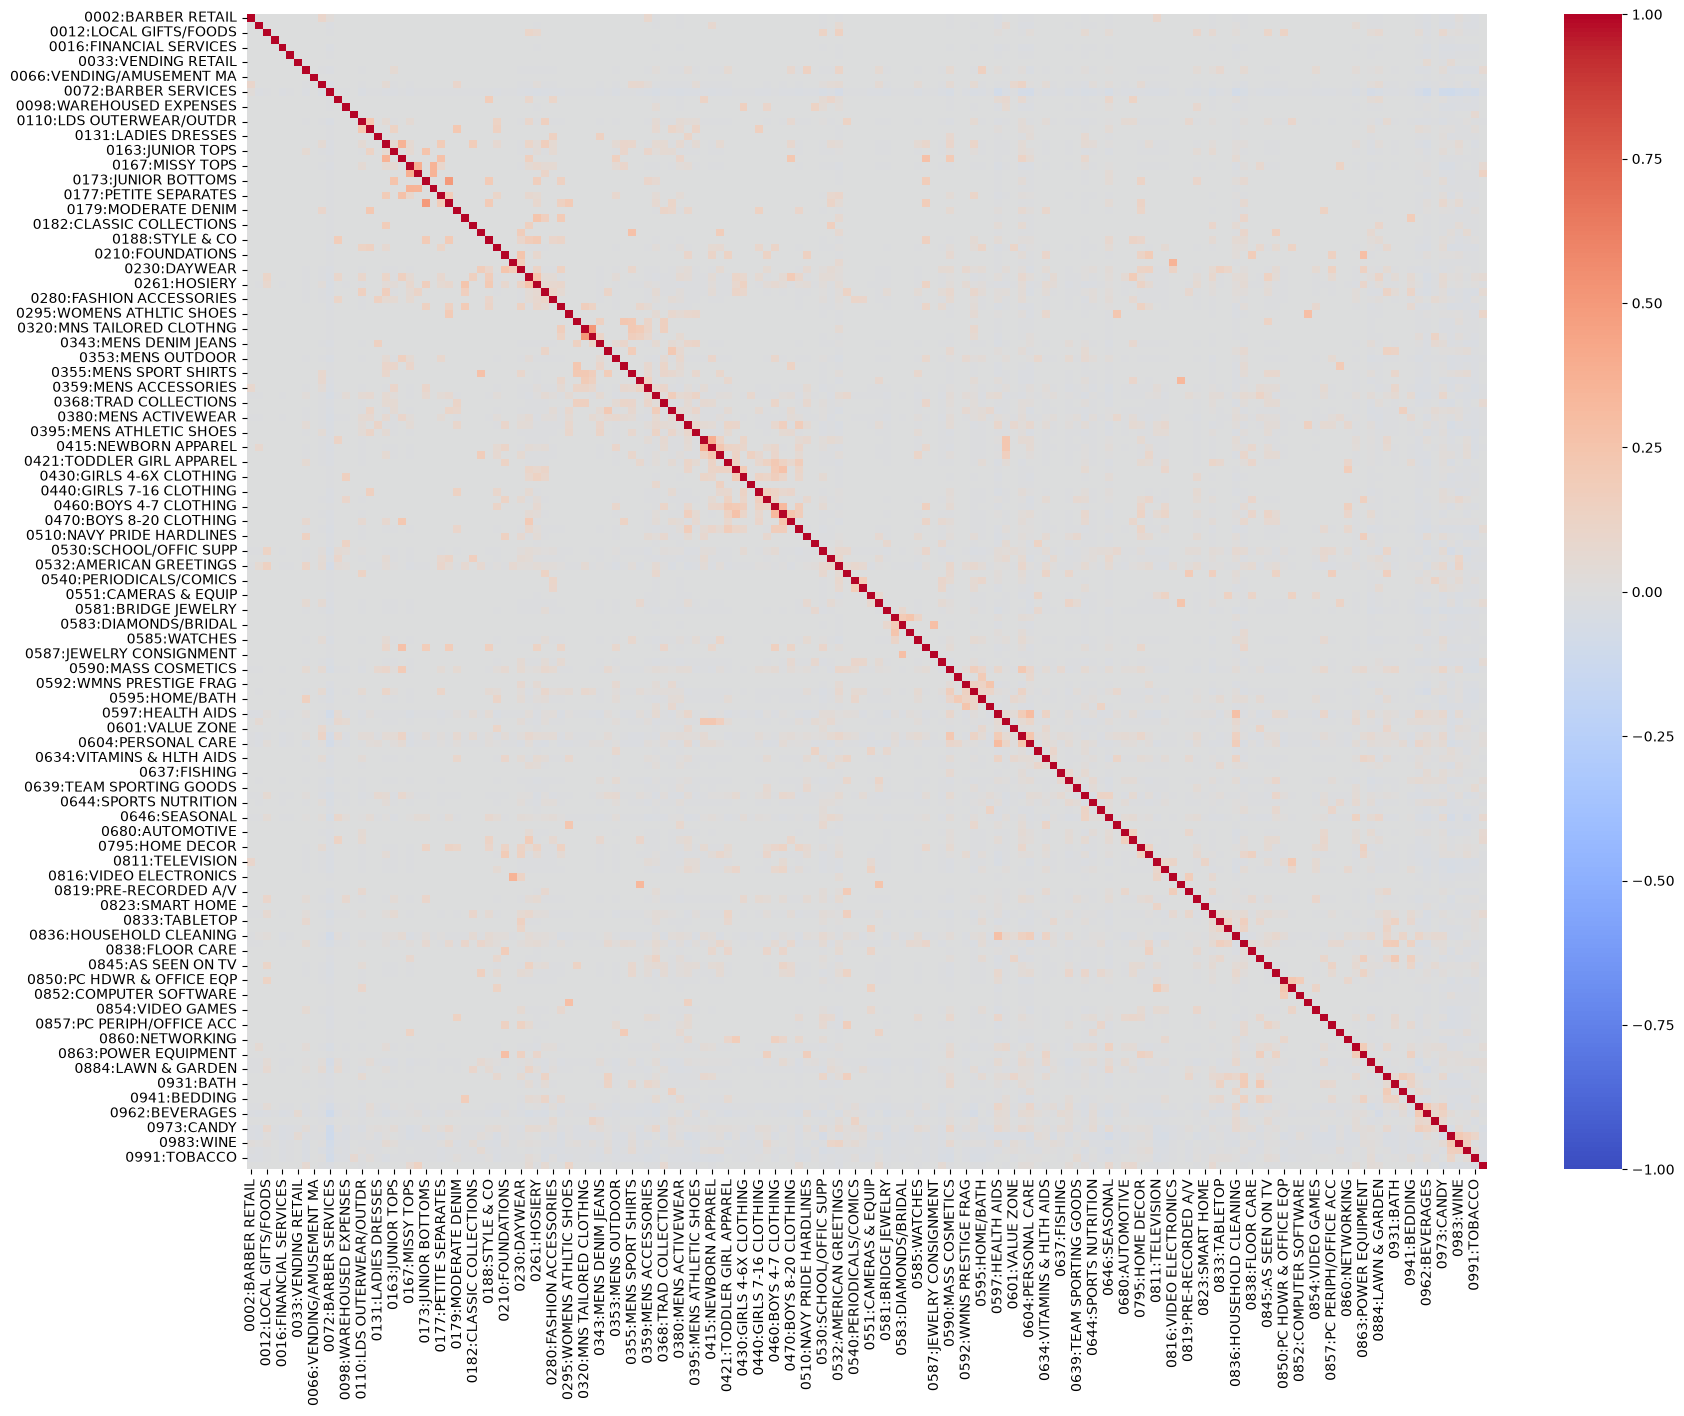

In [44]:
corr_departments = df_transactions_pivot.corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr_departments, cmap='coolwarm', annot=False, vmax=1, vmin=-1)

## Performing Market Basket Analysis with Apriori

In [54]:
# Create a list of common item sets
# Support ranging from 2% to 5%
# Adequate coverage = 40 to 100 transactions
# Diversity across departments, without being restrictive

commom_itemsets = apriori(df_transactions_pivot, min_support=0.02, use_colnames=True, verbose=1)

Processing 6 combinations | Sampling itemset size 3 2


In [55]:
# How many item sets were selected?
len(commom_itemsets)

36

In [56]:
# Creating a column to storage the itemset size
commom_itemsets['itemset_size'] = commom_itemsets['itemsets'].apply(lambda x: len(x))

In [57]:
commom_itemsets

,support,itemsets,itemset_size
0,0.057643,frozenset({0072:BARBER SERVICES}),1
1,0.024704,frozenset({0360:MENS FURNISHINGS}),1
2,0.024189,frozenset({0380:MENS ACTIVEWEAR}),1
3,0.027277,frozenset({0530:SCHOOL/OFFIC SUPP}),1
4,0.053011,frozenset({0532:AMERICAN GREETINGS}),1
5,0.026248,frozenset({0590:MASS COSMETICS}),1
6,0.022645,frozenset({0593:PRESTIGE COSMETICS}),1
7,0.102934,frozenset({0597:HEALTH AIDS}),1
8,0.067936,frozenset({0603:BEAUTY CARE}),1
9,0.077200,frozenset({0604:PERSONAL CARE}),1


In [58]:
# Filtering itemset with at least 2 department
commom_itemsets[commom_itemsets.itemset_size == 2]

,support,itemsets,itemset_size
24,0.021616,"frozenset({0603:BEAUTY CARE, 0597:HEALTH AIDS})",2
25,0.032939,"frozenset({0604:PERSONAL CARE, 0597:HEALTH AIDS})",2
26,0.031395,"frozenset({0836:HOUSEHOLD CLEANING, 0597:HEALT...",2
27,0.023160,"frozenset({0597:HEALTH AIDS, 0973:CANDY})",2
28,0.021101,"frozenset({0603:BEAUTY CARE, 0604:PERSONAL CARE})",2
29,0.022131,"frozenset({0962:BEVERAGES, 0961:GENERAL GROCER...",2
30,0.020072,"frozenset({0973:CANDY, 0961:GENERAL GROCERIES})",2
31,0.034483,"frozenset({0962:BEVERAGES, 0973:CANDY})",2
32,0.025219,"frozenset({0962:BEVERAGES, 0982:SPIRITS})",2
33,0.039629,"frozenset({0983:WINE, 0982:SPIRITS})",2


In [61]:
# Validating the support info EX: SPIRITS
# Support = transactions that contains the itemset / total transactions

transactions_spirits = len(df_transactions_pivot[df_transactions_pivot['0982:SPIRITS'] == True])
transactions_total = len(df_transactions_pivot)

spirits_support = transactions_spirits / transactions_total
spirits_support

0.16160576428203807

### Generating the Association Rules

In [62]:
# Using confidence = 40%
assoc_rules = association_rules(commom_itemsets, metric='confidence', min_threshold=0.4)
assoc_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({0604:PERSONAL CARE}),frozenset({0597:HEALTH AIDS}),0.077200,0.102934,0.032939,0.426667,4.145067,1.0,0.024992,1.564651,0.822225,0.223776,0.360880,0.373333
1,frozenset({0961:GENERAL GROCERIES}),frozenset({0962:BEVERAGES}),0.050952,0.130211,0.022131,0.434343,3.335689,1.0,0.015496,1.537663,0.737805,0.139159,0.349662,0.302152
2,frozenset({0983:WINE}),frozenset({0982:SPIRITS}),0.098302,0.161606,0.039629,0.403141,2.494598,1.0,0.023743,1.404678,0.664450,0.179907,0.288093,0.324182
